In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.width', 1000)
df=pd.read_csv("data_supply_chain_cleaned.csv",encoding="latin1")

**Data cleaning**

In [2]:
# How many missing values are present in each column of the dataset?
print(df.isnull().sum())

Unnamed: 0                       0
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Email                   0
Customer Fname                   0
Customer Id                      0
Customer Lname                   0
Customer Password                0
Customer Segment                 0
Customer State                   0
Customer Street                  0
Customer Zipcode                 0
Department Id                    0
Department Name                  0
Latitude                         0
Longitude                        0
Market                           0
Order City                       0
Order Country                    0
Order Customer Id   

In [3]:
#print(df.columns)
#df["Order Zipcode"].fillna(df["Order Zipcode"].mean(),inplace=True)
#df["Customer Zipcode"].fillna(df["Customer Zipcode"].mean(),inplace=True)
#df["Customer Lname"].fillna("Unknown",inplace=True)
#df.drop("Product Description",axis=1,inplace=True)
#df.to_csv("data_supply_chain.csv")

In [4]:
#finding the duplicate record
duplicate=df.duplicated().sum()
print( "Total duplicate data count :",duplicate)


Total duplicate data count : 0


In [5]:
#Category distribution analysis

x=df.groupby("Delivery Status")["Delivery Status"].count()
y=df.groupby("Delivery Status")["Delivery Status"].count().mean()
print(x)
print("\nMean of the delivery status :",y)
 

Delivery Status
Advance shipping     41592
Late delivery        98977
Shipping canceled     7754
Shipping on time     32196
Name: Delivery Status, dtype: int64

Mean of the delivery status : 45129.75


In [6]:
# Average Delay by Shipping Mode

df["delay_status"]=df["Days for shipping (real)"]-df["Days for shipment (scheduled)"]
delay=df.groupby("Shipping Mode")["delay_status"].mean()
print(delay)

Shipping Mode
First Class       1.000000
Same Day          0.478279
Second Class      1.990828
Standard Class   -0.004093
Name: delay_status, dtype: float64


In [7]:
#Top Cities with Highest Delay

df["delay_status"]=df["Days for shipping (real)"]-df["Days for shipment (scheduled)"]
city=df[df["delay_status"]>0].groupby("Order City")["delay_status"].sum().sort_values(ascending=False)
print(city.head(50))

Order City
Santo Domingo       2089
New York City       2059
Managua             1610
Los Angeles         1538
Mexico City         1478
Tegucigalpa         1461
San Francisco       1291
Manila              1275
London              1180
Philadelphia        1116
San Salvador        1091
Viena                985
Yakarta              942
Seattle              907
BerlÃ­n              898
Bangkok              886
Lagos                852
Houston              822
San Pedro Sula       796
Buenos Aires         784
SÃ£o Paulo           761
Sydney               707
Chicago              707
LeÃ³n                693
Paris                692
Melbourne            685
Mixco                664
Estambul             658
Estocolmo            625
Madrid               622
Panama City          618
Hamburgo             616
Soyapango            601
Brisbane             591
Perth                588
San Miguelito        558
Gold Coast           552
Puebla               540
Cairo                536
Villa Nueva   

In [8]:
#Delay by Product Category

df["delay_status"]=df["Days for shipping (real)"]-df["Days for shipment (scheduled)"]
d1=df[df["delay_status"]>0].groupby("Product Name")["delay_status"].sum()
print(d1)

Product Name
Adult dog supplies                               489
Baby sweater                                     168
Bag Boy Beverage Holder                          253
Bag Boy M330 Push Cart                            61
Bowflex SelectTech 1090 Dumbbells                 10
                                                ... 
adidas Kids' F5 Messi FG Soccer Cleat            258
adidas Men's F10 Messi TRX FG Soccer Cleat       283
adidas Men's Germany Black Crest Away Tee        313
adidas Youth Germany Black/Red Away Match Soc    283
insta-bed Neverflat Air Mattress                  48
Name: delay_status, Length: 118, dtype: int64


In [9]:
# Late delivery risk count

x=df[df["Late_delivery_risk"]==1]["Late_delivery_risk"].count()
print("Total late delivery risk :",x)

Total late delivery risk : 98977


In [10]:
# profit impact delay
df["delay_status"]=df["Days for shipping (real)"]-df["Days for shipment (scheduled)"]
delay_profit=df[df["delay_status"]>0]["Benefit per order"].sum()
on_time_profit=df[df["delay_status"]<=0]["Benefit per order"].sum()
print(delay_profit)
print(on_time_profit)
if delay_profit>on_time_profit:
    print("Company makes loss")
else:
    print("Compant makes profit")

2231966.651613417
1734936.32243694
Company makes loss


Delivery Status
Advance shipping     41592
Late delivery        98977
Shipping canceled     7754
Shipping on time     32196
Name: Delivery Status, dtype: int64


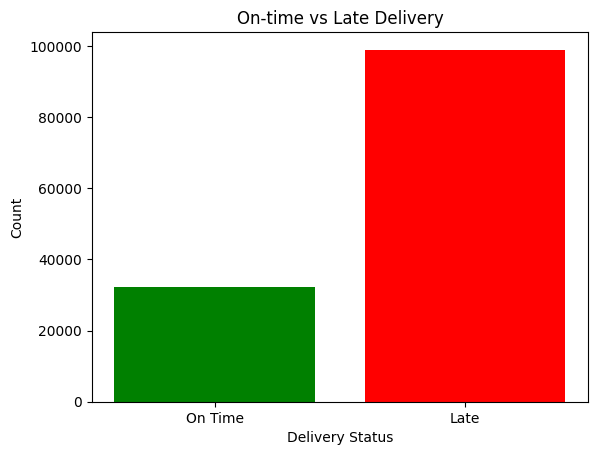

In [11]:
# On time vs late delivery

g1=df.groupby("Delivery Status")["Delivery Status"].count()
print(g1)

x = df[df["Delivery Status"]=="Shipping on time"].shape[0]
y = df[df["Delivery Status"]=="Late delivery"].shape[0]

plt.bar(["On Time", "Late"], [x, y], color=["green", "red"])


plt.title("On-time vs Late Delivery")
plt.xlabel("Delivery Status")
plt.ylabel("Count")
plt.show()


Axes(0.125,0.11;0.775x0.77)


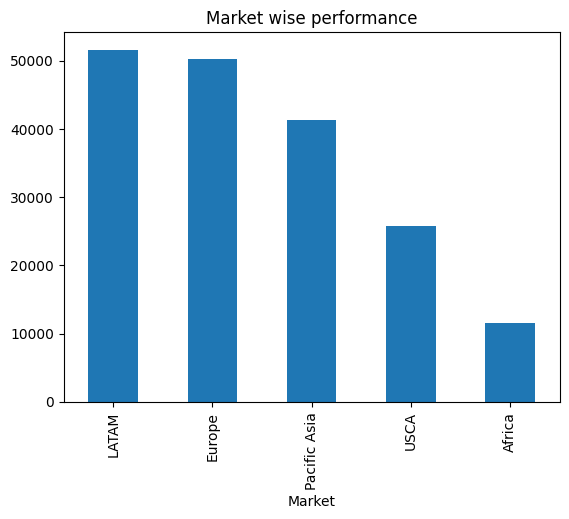

In [12]:
# Market wise performance
x=df["Market"].value_counts().plot(kind="bar",title="Market wise performance")
print(x)


In [13]:
#Revenue loss due to delay
df["delay_status"]=df["Days for shipping (real)"]-df["Days for shipment (scheduled)"]
x=df[(df["delay_status"]>0) & (df["Benefit per order"]<0)]
print(x)
print("Total :",x["Benefit per order"].count())



        Unnamed: 0      Type  Days for shipping (real)  Days for shipment (scheduled)  Benefit per order  Sales per customer Delivery Status  Late_delivery_risk  Category Id   Category Name  ... Order Zipcode Product Card Id Product Category Id                                      Product Image                               Product Name Product Price Product Status shipping date (DateOrders)   Shipping Mode delay_status
1                1  TRANSFER                         5                              4        -249.089996          311.359985   Late delivery                   1           73  Sporting Goods  ...  55426.132327            1360                  73       http://images.acmesports.sports/Smart+watch                                Smart watch     327.750000              0            1/18/2018 12:27  Standard Class            1
15              15     DEBIT                         2                              1        -259.579987          324.470001   Late delivery            

Shipping Mode
First Class       0.953225
Same Day          0.457430
Second Class      0.766328
Standard Class    0.380717
Name: Late_delivery_risk, dtype: float64


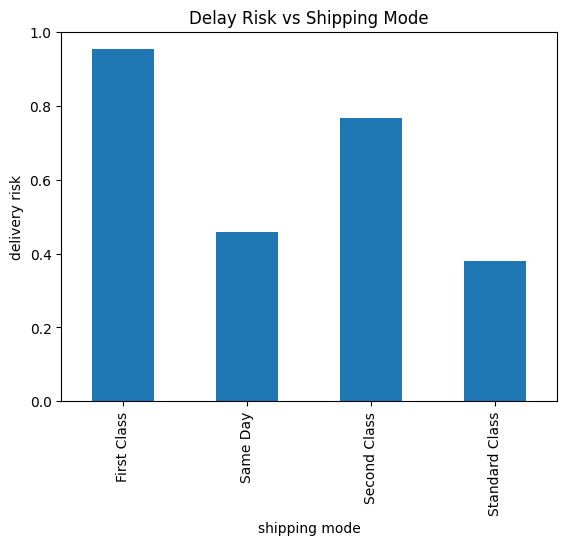

In [14]:
#Delay Risk vs Shipping Mode (Correlation Type Insight)
c1=df.groupby("Shipping Mode")["Late_delivery_risk"].mean()
print(c1)
c1.plot(kind="bar")
plt.title("Delay Risk vs Shipping Mode")
plt.xlabel("shipping mode")
plt.ylabel("delivery risk")
plt.show()


In [15]:
#Identify High-Risk Shipments (Smart Filtering)
high_risk=df[(df["Benefit per order"]<0) & (df["Late_delivery_risk"]==1 & (df["delay_status"]>2))]
h1=df.groupby("Shipping Mode")
print(high_risk)



        Unnamed: 0      Type  Days for shipping (real)  Days for shipment (scheduled)  Benefit per order  Sales per customer    Delivery Status  Late_delivery_risk  Category Id   Category Name  ... Order Zipcode Product Card Id Product Category Id                                      Product Image                                   Product Name Product Price Product Status shipping date (DateOrders)   Shipping Mode delay_status
2                2      CASH                         4                              4        -247.779999          309.720001   Shipping on time                   0           73  Sporting Goods  ...  55426.132327            1360                  73       http://images.acmesports.sports/Smart+watch                                    Smart watch     327.750000              0            1/17/2018 12:06  Standard Class            0
16              16   PAYMENT                         5                              2        -246.360001          321.200012      Late del

In [16]:
#Top 10 Worst Performing Routes
df["is_late"] = (df["Late_delivery_risk"] == 1).astype(int)
df["is_loss"] = (df["Benefit per order"] < 0).astype(int)
df["high_delay"] = (df["delay_status"] > 1).astype(int)

w_routes = df.groupby("Order Region").agg({
    "is_late": "mean",
    "is_loss": "mean",
    "high_delay": "mean"
}).sort_values("is_late",ascending=False).head(10)

print(w_routes)

                 is_late   is_loss  high_delay
Order Region                                  
Central Africa  0.579606  0.199165    0.242695
South Asia      0.562670  0.190014    0.244082
East Africa     0.559395  0.173326    0.234881
Western Europe  0.558486  0.188277    0.241138
South of  USA   0.557726  0.183189    0.251174
Eastern Europe  0.556633  0.197194    0.239796
East of USA     0.556616  0.185973    0.236298
Southeast Asia  0.555299  0.187651    0.238285
Central Asia    0.553345  0.166365    0.258590
West Asia       0.552837  0.185389    0.232318

In [17]:
#How many orders are cancelled / completed / fraud?
#x=df.groupby("Order Status")[(df["Order Status"]=="CANCELED") | (df["Order Status"]=="COMPLETE")|(df["Order Status"]=="SUSPECTED_FRAUD")]
x = df["Order Status"].value_counts().loc[["CANCELED", "COMPLETE", "SUSPECTED_FRAUD"]]
print(x)

Order Status
CANCELED            3692
COMPLETE           59491
SUSPECTED_FRAUD     4062
Name: count, dtype: int64


System slows down based on shipping mode
Shipping Mode
Second Class      1.990828
First Class       1.000000
Same Day          0.478279
Standard Class   -0.004093
Name: delay_status, dtype: float64
Highest : Second Class



System slows down based on Regions
Highest : Central Asia
Order Region
Central Asia      0.645570
Central Africa    0.639833
South Asia        0.597465
Western Europe    0.597403
US Center         0.587226
East of USA       0.584816
South of  USA     0.579975
Eastern Europe    0.579847
East Africa       0.570734
West Asia         0.569479
Name: delay_status, dtype: float64


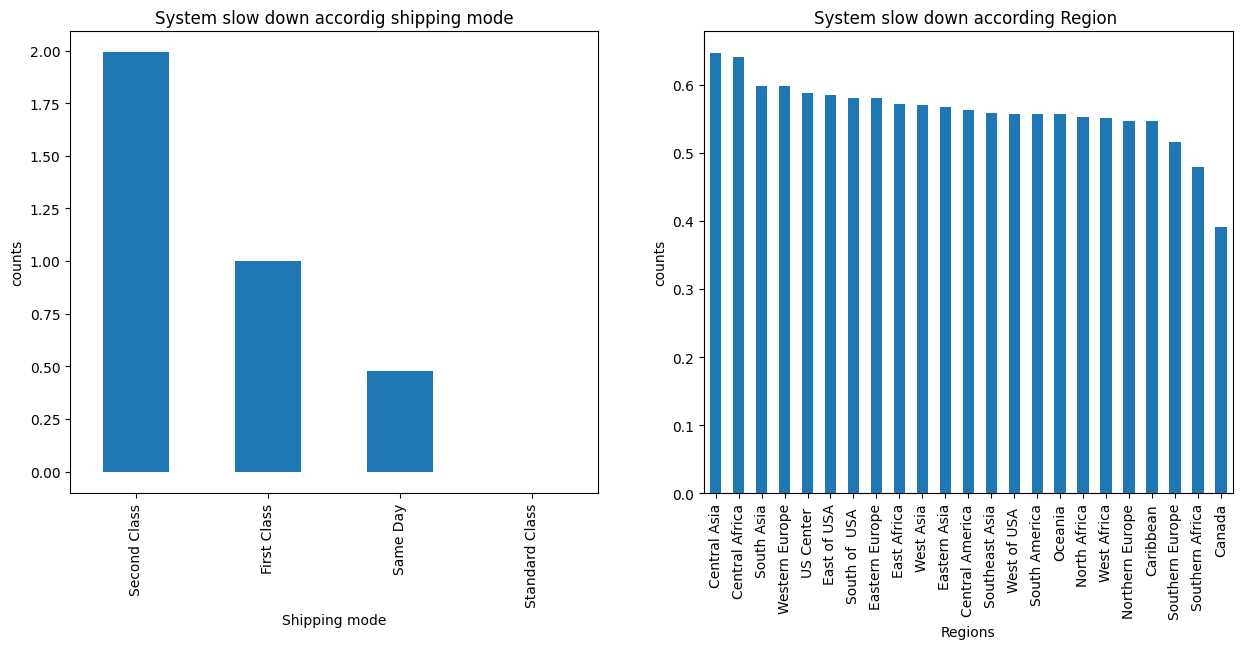

In [18]:
#Where is the system slowing down?
df["delay_status"]=df["Days for shipping (real)"]-df["Days for shipment (scheduled)"]
x1=df.groupby("Shipping Mode")["delay_status"].mean().sort_values(ascending=False)
x2=df.groupby("Order Region")["delay_status"].mean().sort_values(ascending=False).head(10)

fig,ax=plt.subplots(1,2,figsize=(15,6))
g1=df.groupby("Shipping Mode")["delay_status"].mean().sort_values(ascending=False).plot(kind="bar",ax=ax[0])
ax[0].set_title("System slow down accordig shipping mode")
ax[0].set_xlabel("Shipping mode")
ax[0].set_ylabel("counts")

g2=df.groupby("Order Region")["delay_status"].mean().sort_values(ascending=False).plot(kind="bar",ax=ax[1])
ax[1].set_title("System slow down according Region ")
ax[1].set_xlabel("Regions")
ax[1].set_ylabel("counts")

print("System slows down based on shipping mode")
print(x1)
print("Highest :",x1.idxmax())
print("\n\n")
print("System slows down based on Regions")
print("Highest :",x2.idxmax())
print(x2)
plt.show()

Load by Day:
 Day
Monday       25786
Tuesday      25622
Wednesday    25587
Thursday     25752
Friday       25925
Saturday     25901
Sunday       25946
Name: count, dtype: int64
Highest load day: Sunday

Load by Month:
 Month
January      17979
February     14529
March        15919
April        15435
May          15976
June         15139
July         15922
August       15912
September    15489
October      12955
November     12500
December     12764
Name: count, dtype: int64
Highest load month: January


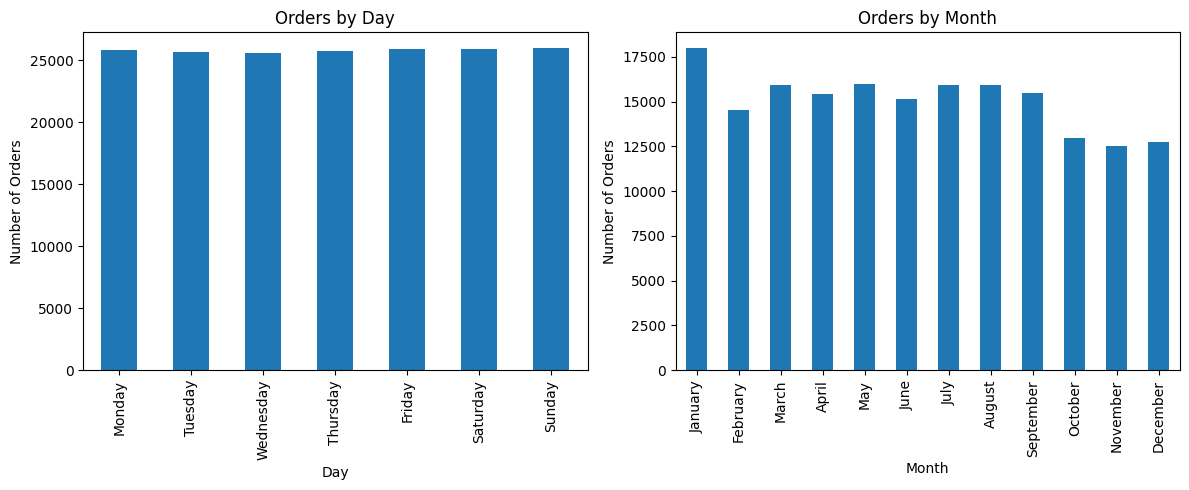

In [19]:
#Which days/months have highest load?



# Convert date column
df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"])

# Extract Day & Month
df["Day"] = df["order date (DateOrders)"].dt.day_name()
df["Month"] = df["order date (DateOrders)"].dt.month_name()

# Order for correct sorting
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

# Load calculation
day_load = df["Day"].value_counts().reindex(day_order)
month_load = df["Month"].value_counts().reindex(month_order)

# Print results
print("Load by Day:\n", day_load)
print("Highest load day:", day_load.idxmax())

print("\nLoad by Month:\n", month_load)
print("Highest load month:", month_load.idxmax())

# Plot using subplots
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Day plot
day_load.plot(kind="bar", ax=ax[0])
ax[0].set_title("Orders by Day")
ax[0].set_xlabel("Day")
ax[0].set_ylabel("Number of Orders")

# Month plot
month_load.plot(kind="bar", ax=ax[1])
ax[1].set_title("Orders by Month")
ax[1].set_xlabel("Month")
ax[1].set_ylabel("Number of Orders")

plt.tight_layout()
plt.show()
